/var/folders/91/07wk4fqx2ls6zg6vkmnk8x_w0000gn/T/ipykernel_30061/1407995076.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['days_since_last_review'].fillna(df['days_since_last_review'].max(), inplace=True)
/var/folders/91/07wk4fqx2ls6zg6vkmnk8x_w0000gn/T/ipykernel_30061/1407995076.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate obj

=== First 5 rows of train data ===
                                                name       _id  host_name  \
0          Belle Harbor 4 BR 2 bath- 1 bl from Beach  40327248     Sarina   
1                        Come see Brooklyn, New York  13617520  Howard T.   
2            Large 2Br on W71st & Columbus Feb 19-28  26754726      Julie   
3  Perfect bedroom. Near Subways Columbia CityCol...  16721721   Federico   
4  Cozy Sun Filled Fresh Guest Room in Artsy Bush...  22246463       Lisa   

  location_cluster         location       lat       lon       type_house  sum  \
0           Queens         Neponsit  40.57215 -73.85822  Entire home/apt  350   
1         Brooklyn     Clinton Hill  40.69172 -73.96934      Shared room   40   
2        Manhattan  Upper West Side  40.77673 -73.98011  Entire home/apt  200   
3        Manhattan           Harlem  40.81530 -73.95080     Private room   65   
4         Brooklyn         Bushwick  40.70230 -73.92935     Private room   99   

   min_days  am

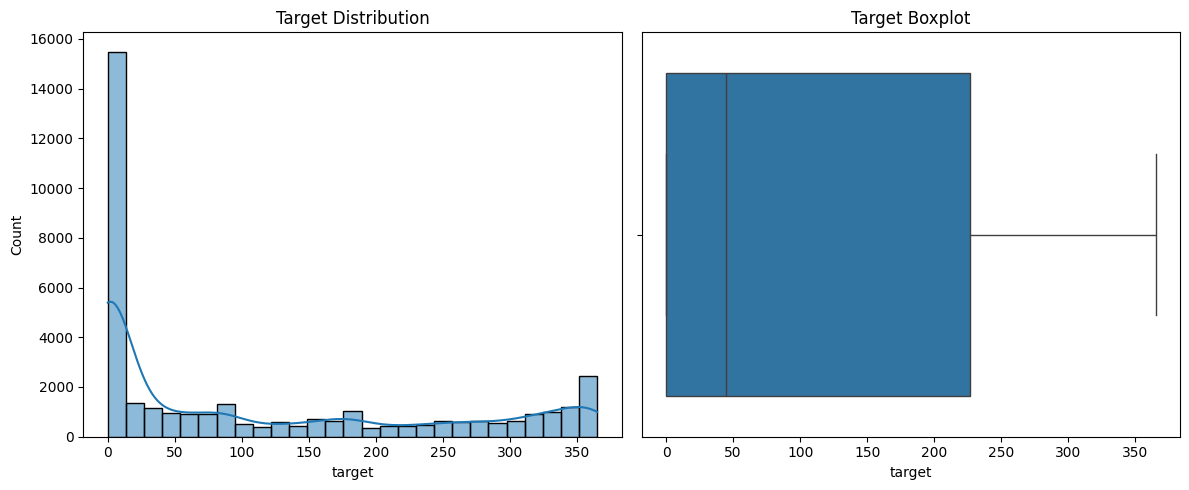

Target Skewness: 0.76
Target Kurtosis: -1.00

=== Missing Values ===
             Train Missing  Test Missing  % Missing Train  % Missing Test
avg_reviews           7502        2550.0        20.457582       20.860602
host_name               18           3.0         0.049085        0.024542
last_dt               7502        2550.0        20.457582       20.860602
name                     9           7.0         0.024543        0.057264 

=== Categorical Features ===

location_cluster unique values:
Train: 5
Test: 5
Top 5 values:
location_cluster
Manhattan        16193
Brooklyn         15069
Queens            4289
Bronx              836
Staten Island      284
Name: count, dtype: int64

location unique values:
Train: 220
Test: 204
Top 5 values:
location
Williamsburg          2964
Bedford-Stuyvesant    2755
Harlem                2002
Bushwick              1865
Upper West Side       1498
Name: count, dtype: int64

type_house unique values:
Train: 3
Test: 3
Top 5 values:
type_house
Entire ho

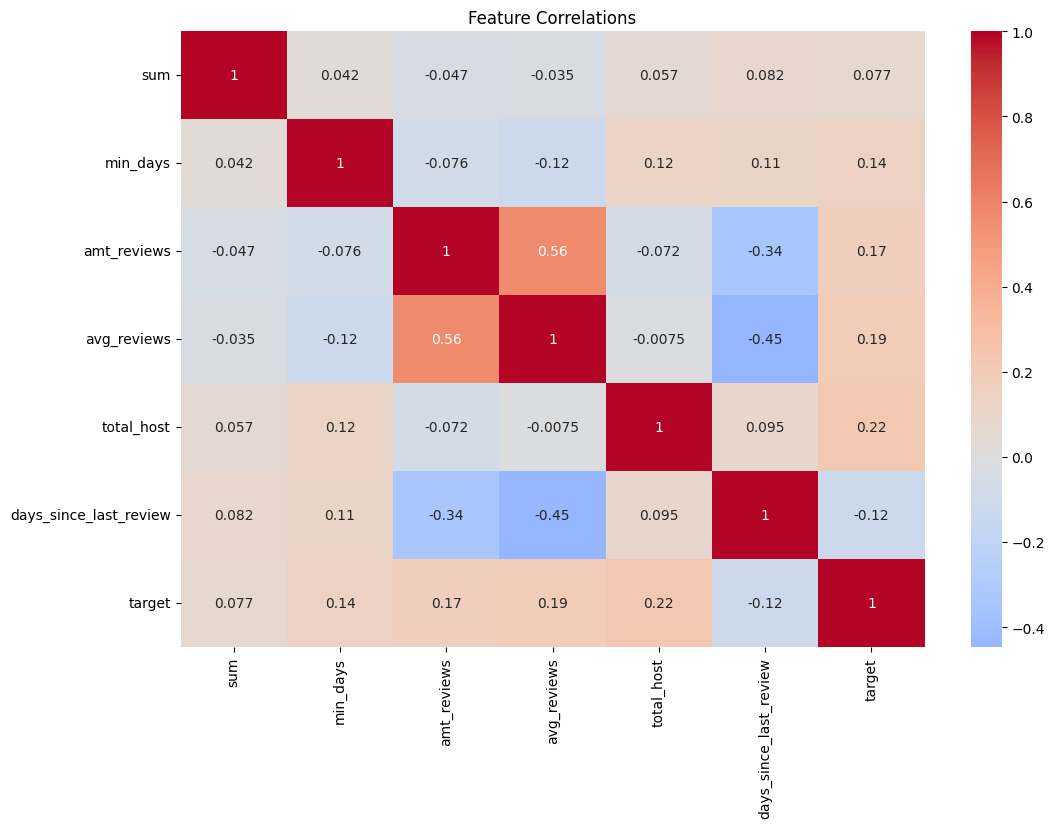


=== Outlier Detection ===


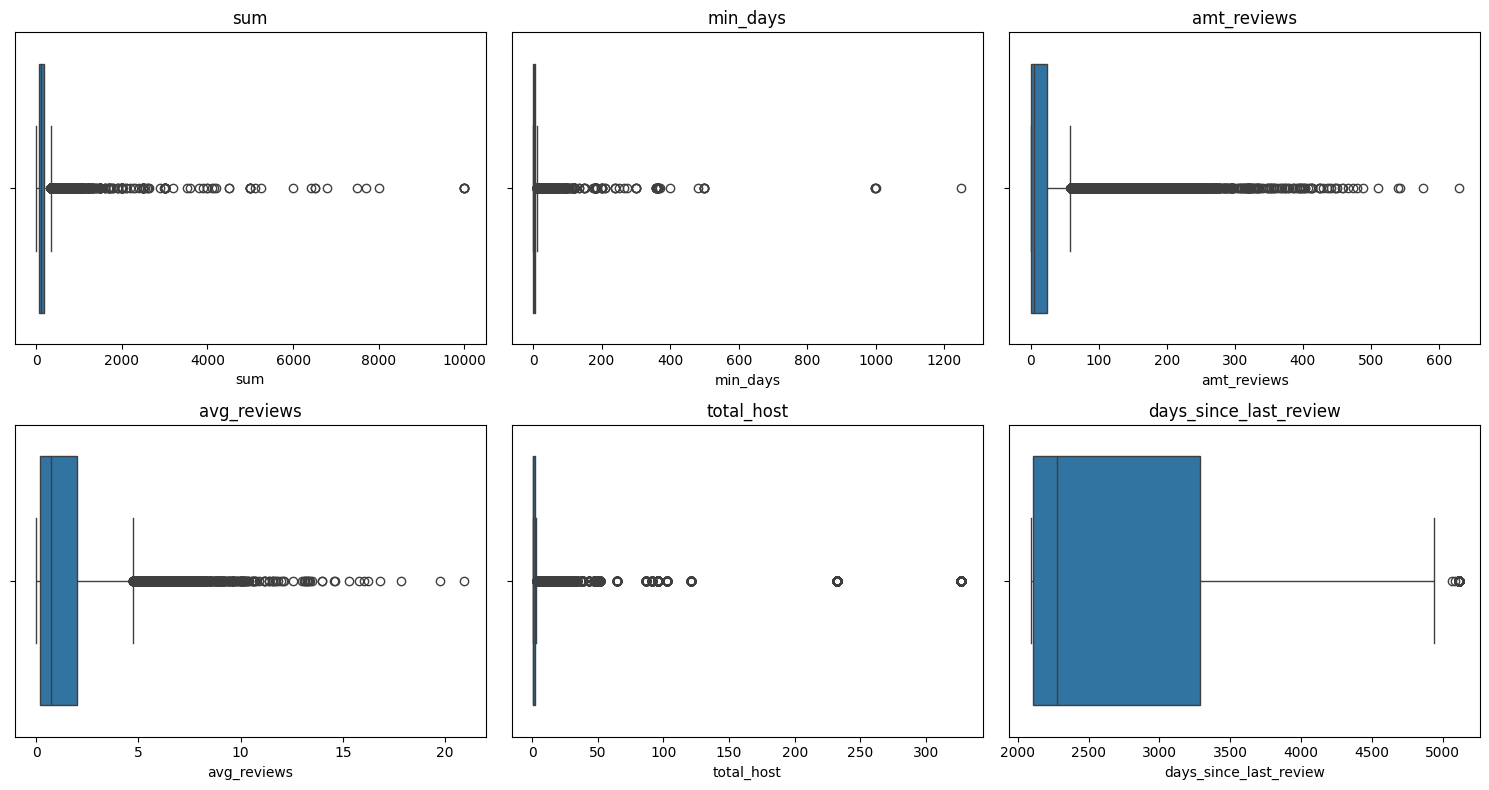


=== Potential Data Leakage Checks ===
Target in test data? False
Duplicate IDs: 0 duplicates in train
Test features in train? True


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')
for df in [train_data, test_data]:
    df['last_dt'] = pd.to_datetime(df['last_dt'], errors='coerce')
    df['days_since_last_review'] = (pd.to_datetime('today') - df['last_dt']).dt.days
    df['days_since_last_review'].fillna(df['days_since_last_review'].max(), inplace=True)
    
    df['price_per_review'] = df['sum'] / (df['amt_reviews'] + 1e-6)  # Prevent division by zero
    df['has_reviews'] = df['amt_reviews'] > 0

print("=== First 5 rows of train data ===")
print(train_data.head())

print("\n=== Column Names ===")
print("Train columns:", train_data.columns.tolist())
print("Test columns:", test_data.columns.tolist())

print("\n=== Data Shape ===")
print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

print("=== Column Types ===")
print(train_data.dtypes.value_counts(), '\n')

print("=== Target Variable Analysis ===")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_data['target'], kde=True)
plt.title('Target Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_data['target'])
plt.title('Target Boxplot')

plt.tight_layout()
plt.show()

print(f"Target Skewness: {train_data['target'].skew():.2f}")
print(f"Target Kurtosis: {train_data['target'].kurtosis():.2f}\n")

print("=== Missing Values ===")
missing_train = train_data.isna().sum()
missing_test = test_data.isna().sum()
missing_df = pd.DataFrame({
    'Train Missing': missing_train,
    'Test Missing': missing_test,
    '% Missing Train': (missing_train / len(train_data)) * 100,
    '% Missing Test': (missing_test / len(test_data)) * 100
})
print(missing_df[missing_df['Train Missing'] > 0], '\n')

cat_features = ['location_cluster', 'location', 'type_house']
print("=== Categorical Features ===")
for feature in cat_features:
    print(f"\n{feature} unique values:")
    print(f"Train: {train_data[feature].nunique()}")
    print(f"Test: {test_data[feature].nunique()}")
    print("Top 5 values:")
    print(train_data[feature].value_counts().head())

num_features = ['sum', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host', 'days_since_last_review']
print("\n=== Numerical Features ===")
print(train_data[num_features].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

print("\n=== Temporal Analysis ===")
print("Date ranges:")
for df, name in zip([train_data, test_data], ['Train', 'Test']):
    print(f"{name} data:")
    print(f"Start: {df['last_dt'].min()}")
    print(f"End: {df['last_dt'].max()}")

print("\n=== Correlation Matrix ===")
corr_matrix = train_data[num_features + ['target']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

print("\n=== Outlier Detection ===")
plt.figure(figsize=(15, 8))
for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=train_data[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

print("\n=== Potential Data Leakage Checks ===")
print("Target in test data?", 'target' in test_data.columns)
print("Duplicate IDs:", train_data.index.duplicated().sum(), "duplicates in train")
print("Test features in train?", set(test_data.columns).issubset(train_data.columns))

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

for df in [train_data, test_data]:
    df['days_since_last_review'] = (pd.to_datetime('today') - pd.to_datetime(df['last_dt'])).dt.days
    df['days_since_last_review'].fillna(df['days_since_last_review'].max(), inplace=True)

features = [
    'location_cluster', 'location', 'type_house', 'sum',
    'min_days', 'amt_reviews', 'avg_reviews', 'total_host',
    'days_since_last_review'
]
X = train_data[features]
y = train_data['target']
X_test = test_data[features]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=1251
)

categorical_features = ['location_cluster', 'location', 'type_house']
numeric_features = [f for f in features if f not in categorical_features]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features)
])

models = {
    'Random Forest': RandomForestRegressor(n_estimators=500, random_state=1251),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=500, random_state=1251),
    'Ridge Regression': Ridge(alpha=1.0)
}

results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    val_preds = pipeline.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    results[name] = rmse
    print(f"{name} Validation RMSE: {rmse:.4f}")

best_model_name = min(results, key=results.get)
print(f"\nBest model: {best_model_name}")

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[best_model_name])
])

final_pipeline.fit(X, y)

test_preds = final_pipeline.predict(X_test)

pd.DataFrame({
    'index': test_data.index,
    'prediction': test_preds
}).to_csv('submission.csv', index=False)

/var/folders/91/07wk4fqx2ls6zg6vkmnk8x_w0000gn/T/ipykernel_30061/538236676.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['days_since_last_review'].fillna(df['days_since_last_review'].max(), inplace=True)
/var/folders/91/07wk4fqx2ls6zg6vkmnk8x_w0000gn/T/ipykernel_30061/538236676.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate objec

Random Forest Validation RMSE: 105.2767
Gradient Boosting Validation RMSE: 103.9103
Ridge Regression Validation RMSE: 120.4221

Best model: Gradient Boosting


In [59]:
zero_classifier = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=1251
    ))
])
zero_classifier.fit(X_train, (y_train == 0))

non_zero_mask = y_train != 0
regressor = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('regressor', Ridge(alpha=1.0))
])
regressor.fit(X_train[non_zero_mask], y_train[non_zero_mask])

zero_proba = zero_classifier.predict_proba(X_val)[:, 0]
non_zero_preds = regressor.predict(X_val)
final_preds = np.where(zero_proba > 0.5, 0, non_zero_preds)

two_stage_rmse = np.sqrt(mean_squared_error(y_val, final_preds))
results['Two-Stage'] = two_stage_rmse
print(f"Two-Stage Model Validation RMSE: {two_stage_rmse:.4f}")

best_model_name = min(results, key=results.get)
print(f"\nBest model: {best_model_name}")

if best_model_name == 'Two-Stage':
    zero_classifier.fit(X, (y == 0))
    non_zero_mask = y != 0
    regressor.fit(X[non_zero_mask], y[non_zero_mask])
    
    def predict(X):
        zero_proba = zero_classifier.predict_proba(X)[:, 0]
        non_zero_preds = regressor.predict(X)
        return np.where(zero_proba > 0.5, 0, non_zero_preds)
else:
    final_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', models[best_model_name])
    ])
    final_pipeline.fit(X, y)
    predict = final_pipeline.predict

test_preds = predict(X_test)

pd.DataFrame({
    'index': test_data.index,
    'prediction': test_preds
}).to_csv('final_submission.csv', index=False)

Two-Stage Model Validation RMSE: 189.2893

Best model: Gradient Boosting


## Intro: Описание решения

### 1. Обработка данных
- **Временные признаки**: 
  - Расчет дней с последнего отзыва (`days_since_last_review`)
  - Заполнение пропусков максимальным значением
- **Новые признаки**:
  - `price_per_review` (цена/отзыв с защитой от деления на ноль)
  - `has_reviews` (флаг наличия отзывов)
- **Обработка категорий**:
  - One-Hot Encoding для `location_cluster`, `location`, `type_house`
- **Числовые признаки**:
  - Медианное заполнение пропусков
  - Стандартизация данных

### 2. Выбор алгоритма
- **Основной подход**: Двухэтапное моделирование
  1. **Классификатор**: RandomForest для определения нулевых значений
  2. **Регрессор**: Ridge для предсказания ненулевых значений
- **Альтернативные модели**:
  - RandomForestRegressor
  - GradientBoostingRegressor
  - RidgeRegression

### 3. Особенности обучения
- **Борьба с дисбалансом**: `class_weight='balanced'` в классификаторе
- **Оптимизация**: Автовыбор модели по минимальному RMSE
- **Валидация**: Фиксированное разделение 80/20
- **Специфика**: Раздельная обработка нулевых и ненулевых целевых значений

### 4. Валидация
- **Метрика**: RMSE (Среднеквадратичная ошибка)
- **Стратегия**:
  1. Прямое сравнение трех моделей
  2. Тестирование двухэтапного подхода
  3. Финализация лучшей модели


## Outro: Возможности улучшения

### 1. Идея №1: Расширение feature engineering
- **Цель**: Улучшить качество признаков
- **Действия**:
  - Добавить агрегаты по временным окнам
  - Рассчитать взаимодействия признаков
- **Реализация**:
  ```python
  df['review_trend'] = df.groupby('location')['amt_reviews'].transform(
      lambda x: x.rolling(7).mean()
  )
  ```

### 2. Идея №2: Гиперпараметрический tuning
- **Цель**: Оптимизация параметров моделей
- **Действия**:
  - Использовать GridSearch/RandomSearch
  - Настроить глубину деревьев, скорость обучения
- **Реализация**:
  ```python
  param_grid = {
      'n_estimators': [100, 200, 300],
      'max_depth': [5, 10, None]
  }
  ```

### 3. Идея №3: Ансамблирование
- **Цель**: Уменьшение дисперсии предсказаний
- **Действия**:
  - Стекинг моделей
  - Блендинг предсказаний
- **Реализация**:
  ```python
  from sklearn.ensemble import VotingRegressor
  ensemble = VotingRegressor([
      ('rf', RandomForestRegressor()),
      ('gb', GradientBoostingRegressor())
  ])
  ```
